### Training XGBoost Model

In [1]:
import pandas as pd
import numpy as np

# Load the raw dataset
csv_path = "../Dataset/agmarknet_india_historical_prices_2024_2025.csv"
print(f"Loading {csv_path}...")
df = pd.read_csv(csv_path)

# Rename the columns to our standard format
df = df.rename(columns={
    "Commodity": "crop",
    "State": "state",
    "Modal Price (Rs./Quintal)": "price",
    "Price Date": "date"
})

# Convert date strings to actual Datetime objects
df['date'] = pd.to_datetime(df['date'])

# Sort chronologically (Crucial for time-series calculations!)
df = df.sort_values(by=['crop', 'state', 'date'])
print(f"Loaded {len(df)} rows.")
df.head(3)


Loading ../Dataset/agmarknet_india_historical_prices_2024_2025.csv...
Loaded 1118899 rows.


,Sl no.,District Name,Market Name,crop,Variety,Grade,Min Price (Rs./Quintal),Max Price (Rs./Quintal),price,date,state
409076,213,Porbandar,Porbandar,Apple,Apple,Large,8000.0,15000.0,11500.0,2024-08-16,Gujarat
409142,279,Bharuch,Bharuch,Apple,Apple,Medium,4000.0,9000.0,5000.0,2024-08-16,Gujarat
409407,544,Bharuch,Bharuch,Apple,Apple,Medium,4000.0,9000.0,7000.0,2024-08-17,Gujarat


In [2]:
# Set date as index to use pandas time-based rolling windows
df = df.set_index('date')

# Calculate 30-day rolling mean for each specific crop in each specific state
print("Calculating 30-day rolling averages...")
df['last_30d_avg_price'] = df.groupby(['crop', 'state'])['price'].transform(
    lambda x: x.rolling('30D').mean()
)

# Bring the date back as a normal column
df = df.reset_index()
df.head(3)


Calculating 30-day rolling averages...


,date,Sl no.,District Name,Market Name,crop,Variety,Grade,Min Price (Rs./Quintal),Max Price (Rs./Quintal),price,state,last_30d_avg_price
0,2024-08-16,213,Porbandar,Porbandar,Apple,Apple,Large,8000.0,15000.0,11500.0,Gujarat,11500.000000
1,2024-08-16,279,Bharuch,Bharuch,Apple,Apple,Medium,4000.0,9000.0,5000.0,Gujarat,8250.000000
2,2024-08-17,544,Bharuch,Bharuch,Apple,Apple,Medium,4000.0,9000.0,7000.0,Gujarat,7833.333333


In [3]:
print("Calculating future target prices...")
# Shift the price backwards by 7 steps to act as our future target
df['target_price_7d'] = df.groupby(['crop', 'state'])['price'].shift(-7)


Calculating future target prices...


In [4]:
def get_season(month):
    if month in (12, 1, 2): return 0   # Winter
    elif month in (3, 4): return 1     # Spring
    elif month in (5, 6): return 2     # Summer
    elif month in (7, 8, 9): return 3  # Monsoon
    else: return 4                     # Autumn

# Extract month and calculate season
df['month'] = df['date'].dt.month
df['season'] = df['month'].apply(get_season)

# Lowercase crops to match backend (e.g. "Wheat" -> "wheat")
df['crop'] = df['crop'].str.lower()

# Drop rows with NaNs (The first 30 days and the very last 7 days of the dataset)
df_clean = df.dropna(subset=['last_30d_avg_price', 'target_price_7d']).copy()

print(f"Final clean dataset has {len(df_clean)} rows ready for training!")
df_clean[['crop', 'state', 'month', 'season', 'last_30d_avg_price', 'target_price_7d']].head(5)


Final clean dataset has 1117883 rows ready for training!


,crop,state,month,season,last_30d_avg_price,target_price_7d
0,apple,Gujarat,8,3,11500.000000,12500.0
1,apple,Gujarat,8,3,8250.000000,12500.0
2,apple,Gujarat,8,3,7833.333333,12500.0
3,apple,Gujarat,8,3,8625.000000,7000.0
4,apple,Gujarat,8,3,9400.000000,7000.0


In [5]:
import sys
# Ensure Python can find the backend models folder
sys.path.append("../Backend")

from models.price_predictor import train_model

print("Training XGBoost Model on Real Data...")
metrics = train_model(data=df_clean)

print("\n✅ SUCCESS: Model Retrained!")
print(f"MAE: ₹{metrics['mae']} per quintal (Average error)")
print(f"R² Score: {metrics['r2_score']} (Accuracy score)")
print(f"Model saved to: {metrics['model_path']}")

Training XGBoost Model on Real Data...

✅ SUCCESS: Model Retrained!
MAE: ₹716.22 per quintal (Average error)
R² Score: 0.6219 (Accuracy score)
Model saved to: /Users/vaibhavbansal/.gemini/antigravity/scratch/KisanMind/Backend/models/../data/price_model.pkl


In [6]:
from models.price_predictor import predict

# Grab 10 random scenarios from our dataset to test
sample_tests = df_clean.sample(10, random_state=42)

print(f"{'Crop':<10} | {'State':<15} | {'Last 30d Avg':<15} | {'Actual 7d Target':<18} | {'Model Prediction':<16} | {'Error (Off by)'}")
print("-" * 100)

for _, row in sample_tests.iterrows():
    # Ask our backend AI to predict the future price
    result = predict(
        crop=row['crop'], 
        state=row['state'], 
        month=int(row['month']), 
        last_price=row['last_30d_avg_price']
    )
    
    predicted = result['predicted_price']
    actual = row['target_price_7d']
    diff = predicted - actual
    
    print(f"{row['crop'].title():<10} | {row['state']:<15} | ₹{row['last_30d_avg_price']:<14.2f} | ₹{actual:<17.2f} | ₹{predicted:<15.2f} | ₹{diff:+.2f}")


Crop       | State           | Last 30d Avg    | Actual 7d Target   | Model Prediction | Error (Off by)
----------------------------------------------------------------------------------------------------
Green Chilli | Uttar Pradesh   | ₹2630.27        | ₹2950.00           | ₹2717.80         | ₹-232.20
Apple      | Uttar Pradesh   | ₹8384.60        | ₹8495.00           | ₹8303.66         | ₹-191.34
Brinjal    | Uttar Pradesh   | ₹1730.22        | ₹1620.00           | ₹1673.11         | ₹+53.11
Mango      | Punjab          | ₹3999.48        | ₹3500.00           | ₹4533.52         | ₹+1033.52
Wheat      | West Bengal     | ₹2741.92        | ₹2550.00           | ₹2685.65         | ₹+135.65
Arhar (Tur/Red Gram)(Whole) | Uttar Pradesh   | ₹7619.38        | ₹7750.00           | ₹7612.54         | ₹-137.46
Brinjal    | Kerala          | ₹4194.53        | ₹5100.00           | ₹4140.24         | ₹-959.76
Bhindi(Ladies Finger) | Uttar Pradesh   | ₹1850.30        | ₹1900.00           | ₹1919.12 

Matplotlib is building the font cache; this may take a moment.


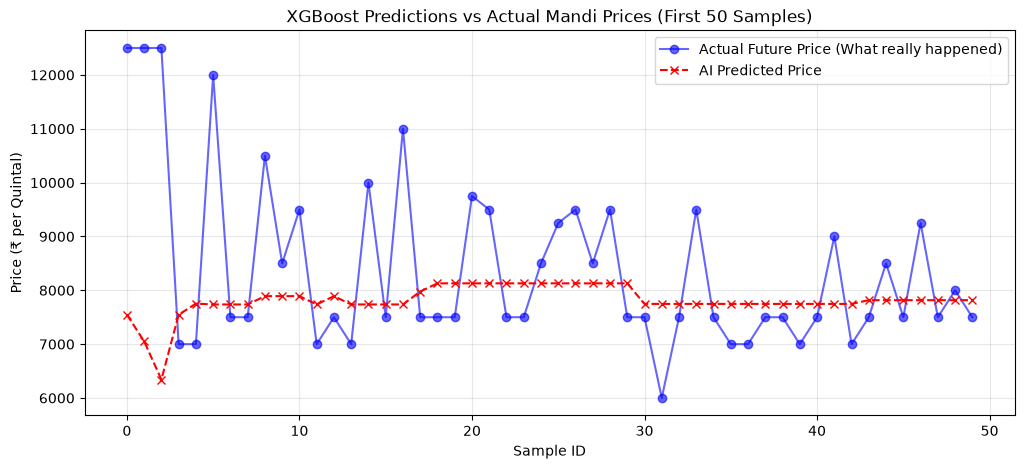

In [8]:
import matplotlib.pyplot as plt

# Take the first 50 rows for a clean graph
viz_data = df_clean.head(50)
actuals = viz_data['target_price_7d'].values
predictions = []

for _, row in viz_data.iterrows():
    res = predict(row['crop'], row['state'], int(row['month']), row['last_30d_avg_price'])
    predictions.append(res['predicted_price'])

plt.figure(figsize=(12, 5))
plt.plot(actuals, label='Actual Future Price (What really happened)', color='blue', marker='o', alpha=0.6)
plt.plot(predictions, label='AI Predicted Price', color='red', linestyle='--', marker='x')

plt.title('XGBoost Predictions vs Actual Mandi Prices (First 50 Samples)')
plt.ylabel('Price (₹ per Quintal)')
plt.xlabel('Sample ID')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [9]:
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
import numpy as np
from models.price_predictor import predict

# Let's take a larger random sample of 500 scenarios to get a robust score
eval_data = df_clean.sample(500, random_state=99)

actuals = eval_data['target_price_7d'].values
predictions = []

print("Running 500 predictions for evaluation...")
for _, row in eval_data.iterrows():
    res = predict(row['crop'], row['state'], int(row['month']), row['last_30d_avg_price'])
    predictions.append(res['predicted_price'])

predictions = np.array(predictions)

# Calculate Advanced Metrics
rmse = np.sqrt(mean_squared_error(actuals, predictions))
mape = mean_absolute_percentage_error(actuals, predictions) * 100

print("\n📊 Advanced Model Accuracy Scores")
print("-" * 50)
print(f"RMSE (Root Mean Squared Error) : ₹{rmse:.2f} per quintal")
print(f"MAPE (Mean Abs Percentage Error): {mape:.2f}%")
print(f"Overall Prediction Accuracy    : {(100 - mape):.2f}%")

Running 500 predictions for evaluation...

📊 Advanced Model Accuracy Scores
--------------------------------------------------
RMSE (Root Mean Squared Error) : ₹1229.26 per quintal
MAPE (Mean Abs Percentage Error): 42.27%
Overall Prediction Accuracy    : 57.73%


In [11]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

from xgboost import XGBRegressor

### Feature Engineering
Re-evaluate model to improve accuracy

In [12]:
# =====================================================
# SORT DATA
# =====================================================

df_clean = df_clean.sort_values("date").copy()

# =====================================================
# SPREAD
# =====================================================

if 'max_price' in df_clean.columns and 'min_price' in df_clean.columns:
    df_clean['spread'] = (
        df_clean['max_price']
        - df_clean['min_price']
    )

# =====================================================
# LAGS
# =====================================================

group_cols = ['crop', 'state']

df_clean['lag_1'] = (
    df_clean.groupby(group_cols)['price']
    .shift(1)
)

df_clean['lag_7'] = (
    df_clean.groupby(group_cols)['price']
    .shift(7)
)

df_clean['lag_30'] = (
    df_clean.groupby(group_cols)['price']
    .shift(30)
)

# =====================================================
# ROLLING FEATURES
# =====================================================

df_clean['rolling_7_mean'] = (
    df_clean.groupby(group_cols)['price']
    .transform(
        lambda x:
        x.shift(1).rolling(7).mean()
    )
)

df_clean['rolling_30_mean'] = (
    df_clean.groupby(group_cols)['price']
    .transform(
        lambda x:
        x.shift(1).rolling(30).mean()
    )
)

df_clean['rolling_7_std'] = (
    df_clean.groupby(group_cols)['price']
    .transform(
        lambda x:
        x.shift(1).rolling(7).std()
    )
)

df_clean['rolling_30_std'] = (
    df_clean.groupby(group_cols)['price']
    .transform(
        lambda x:
        x.shift(1).rolling(30).std()
    )
)

df_clean = df_clean.dropna().copy()

print("Rows:", len(df_clean))

Rows: 1109290


### Encoding

In [13]:
categorical_cols = []

for col in [
    'crop',
    'state',
    'district',
    'market',
    'variety',
    'grade'
]:
    if col in df_clean.columns:
        categorical_cols.append(col)

print("Categorical columns:")
print(categorical_cols)

for col in categorical_cols:
    le = LabelEncoder()

    df_clean[col] = (
        le.fit_transform(
            df_clean[col].astype(str)
        )
    )

Categorical columns:
['crop', 'state']


### Feature Selection

In [15]:
possible_features = [
    'crop',
    'state',

    # Uncomment later if present
    # 'district',
    # 'market',
    # 'variety',
    # 'grade',

    'month',
    'season',

    'price',
    'last_30d_avg_price',

    'lag_1',
    'lag_7',
    'lag_30',

    'rolling_7_mean',
    'rolling_30_mean',

    'rolling_7_std',
    'rolling_30_std',

    # 'spread'
]

feature_cols = [
    c for c in possible_features
    if c in df_clean.columns
]

target_col = 'target_price_7d'

X = df_clean[feature_cols]
y = df_clean[target_col]

print("Features Used:")
for f in feature_cols:
    print("-", f)

Features Used:
- crop
- state
- month
- season
- price
- last_30d_avg_price
- lag_1
- lag_7
- lag_30
- rolling_7_mean
- rolling_30_mean
- rolling_7_std
- rolling_30_std


### Train/Test Split

In [16]:
split_idx = int(
    len(df_clean) * 0.8
)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

print("Train:", len(X_train))
print("Test :", len(X_test))

Train: 887432
Test : 221858


### Re-Train XGBoost

In [17]:
model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=8,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train,
    y_train
)

print("Training Complete")

Training Complete


### Evaluate

In [18]:
preds = model.predict(X_test)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        preds
    )
)

mape = (
    mean_absolute_percentage_error(
        y_test,
        preds
    ) * 100
)

r2 = r2_score(
    y_test,
    preds
)

print("="*50)
print("RESULTS")
print("="*50)

print(f"RMSE : ₹{rmse:.2f}")
print(f"MAPE : {mape:.2f}%")
print(f"R²   : {r2:.4f}")

RESULTS
RMSE : ₹1143.21
MAPE : 20.79%
R²   : 0.8298


### Feature Importance

In [19]:
importance_df = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": model.feature_importances_
})

importance_df = (
    importance_df
    .sort_values(
        "Importance",
        ascending=False
    )
)

importance_df.head(20)

,Feature,Importance
10,rolling_30_mean,0.508770
5,last_30d_avg_price,0.192897
9,rolling_7_mean,0.070158
11,rolling_7_std,0.029195
2,month,0.029168
3,season,0.026008
4,price,0.024283
6,lag_1,0.023784
8,lag_30,0.022440
7,lag_7,0.021934


### Prediction Samples

In [20]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": preds
})

comparison.head(25)

,Actual,Predicted
0,6050.0,6082.988770
1,5960.0,6082.988770
2,5975.0,6091.315918
3,3400.0,4051.962646
4,6075.0,6094.461426
5,6300.0,6098.580566
6,4145.0,4086.676025
7,4366.0,4093.463623
8,6300.0,6100.479004
9,900.0,1841.526733



EXPERIMENT: ADD DISTRICT / MARKET / VARIETY / GRADE


Goal:
Test whether additional categorical information
improves crop price prediction.

Added Features:
District Name
Market Name
Variety
Grade

Encoding:LabelEncoder used on all four columns.

 Result:
 Baseline:
   R²   = 0.8326
   MAPE = 20.58%

 With additional categorical features:
   R²   = 0.8208
   MAPE = 20.90%

 Conclusion:
 Performance decreased.

 Likely reasons:
 1. Historical price features already capture most
    predictive information.
 2. Label Encoding introduces artificial ordering
    between categories.
 3. Additional categorical features added noise
    rather than useful signal.

 Decision:
 Reverted to baseline feature set.
 Future work: Test CatBoost or target encoding
 for high-cardinality categorical features.

In [35]:
pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.9/28.9 MB 2.7 MB/s  0:00:10m0:00:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 3.8 MB/s  0:00:02 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [catboost]2/3 [catboost]

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
# from catboost import CatBoostRegressor
# from sklearn.metrics import (
#     mean_squared_error,
#     mean_absolute_percentage_error,
#     r2_score
# )
# import numpy as np
# import pandas as pd

# # ==========================================
# # SAME FEATURES AS BEST XGBOOST MODEL
# # ==========================================

# feature_cols_cat = [
#     'crop',
#     'state',
#     'month',
#     'season',
#     'price',
#     'last_30d_avg_price',
#     'lag_1',
#     'lag_7',
#     'lag_30',
#     'rolling_7_mean',
#     'rolling_30_mean',
#     'rolling_7_std',
#     'rolling_30_std'
# ]

# X_cat = df_clean[feature_cols_cat]
# y_cat = df_clean['target_price_7d']

# split_idx = int(len(df_clean) * 0.8)

# X_train_cat = X_cat.iloc[:split_idx]
# X_test_cat = X_cat.iloc[split_idx:]

# y_train_cat = y_cat.iloc[:split_idx]
# y_test_cat = y_cat.iloc[split_idx:]

# # ==========================================
# # CATBOOST
# # ==========================================

# model_cat = CatBoostRegressor(
#     iterations=1000,
#     learning_rate=0.03,
#     depth=8,
#     loss_function='RMSE',
#     eval_metric='RMSE',
#     random_seed=42,
#     verbose=100
# )

# model_cat.fit(
#     X_train_cat,
#     y_train_cat
# )

# # ==========================================
# # EVALUATION
# # ==========================================

# preds_cat = model_cat.predict(X_test_cat)

# rmse_cat = np.sqrt(
#     mean_squared_error(
#         y_test_cat,
#         preds_cat
#     )
# )

# mape_cat = (
#     mean_absolute_percentage_error(
#         y_test_cat,
#         preds_cat
#     ) * 100
# )

# r2_cat = r2_score(
#     y_test_cat,
#     preds_cat
# )

# print("\n" + "="*60)
# print("CATBOOST RESULTS")
# print("="*60)

# print(f"RMSE : ₹{rmse_cat:.2f}")
# print(f"MAPE : {mape_cat:.2f}%")
# print(f"R²   : {r2_cat:.4f}")

# importance_cat = pd.DataFrame({
#     'Feature': feature_cols_cat,
#     'Importance': model_cat.feature_importances_
# })

# importance_cat = importance_cat.sort_values(
#     'Importance',
#     ascending=False
# )

# print("\nTOP FEATURES")
# print(importance_cat.head(15))

0:	learn: 4782.8633284	total: 89.6ms	remaining: 1m 29s
100:	learn: 3149.9102959	total: 2.25s	remaining: 20s
200:	learn: 3101.1808958	total: 4.25s	remaining: 16.9s
300:	learn: 3059.1612859	total: 6.29s	remaining: 14.6s
400:	learn: 3017.5800246	total: 8.4s	remaining: 12.6s
500:	learn: 2980.7510552	total: 10.4s	remaining: 10.3s
600:	learn: 2947.0687113	total: 12.4s	remaining: 8.21s
700:	learn: 2914.8788880	total: 14.4s	remaining: 6.14s
800:	learn: 2886.8319921	total: 16.4s	remaining: 4.08s
900:	learn: 2852.5282135	total: 18.3s	remaining: 2.02s
999:	learn: 2828.3493089	total: 20.3s	remaining: 0us

CATBOOST RESULTS
RMSE : ₹1140.53
MAPE : 20.71%
R²   : 0.8306

TOP FEATURES
               Feature  Importance
10     rolling_30_mean   23.667463
5   last_30d_avg_price   11.997607
4                price   11.426027
7                lag_7    8.761394
11       rolling_7_std    8.478035
6                lag_1    7.687053
8               lag_30    7.156356
12      rolling_30_std    6.392893
9       r

In [ ]:
# # ==========================================
# # EXPERIMENT: TREND FEATURES
# # ==========================================

# # Create trend features
# df_clean['change_7d'] = (
#     df_clean['price']
#     - df_clean['lag_7']
# )

# df_clean['change_30d'] = (
#     df_clean['price']
#     - df_clean['lag_30']
# )

# df_clean['pct_change_7d'] = (
#     (df_clean['price'] - df_clean['lag_7'])
#     / (df_clean['lag_7'] + 1e-8)
# )

# df_clean['pct_change_30d'] = (
#     (df_clean['price'] - df_clean['lag_30'])
#     / (df_clean['lag_30'] + 1e-8)
# )

# # Feature set
# feature_cols_trend = [

#     'crop',
#     'state',

#     'month',
#     'season',

#     'price',

#     'last_30d_avg_price',

#     'lag_1',
#     'lag_7',
#     'lag_30',

#     'rolling_7_mean',
#     'rolling_30_mean',

#     'rolling_7_std',
#     'rolling_30_std',

#     # NEW
#     'change_7d',
#     'change_30d',
#     'pct_change_7d',
#     'pct_change_30d'
# ]

# X_trend = df_clean[feature_cols_trend]
# y_trend = df_clean['target_price_7d']

# # Same split as baseline
# split_idx = int(len(df_clean) * 0.8)

# X_train = X_trend.iloc[:split_idx]
# X_test = X_trend.iloc[split_idx:]

# y_train = y_trend.iloc[:split_idx]
# y_test = y_trend.iloc[split_idx:]

# # Same XGBoost as baseline
# model_trend = XGBRegressor(
#     n_estimators=1000,
#     learning_rate=0.03,
#     max_depth=8,
#     min_child_weight=5,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     objective='reg:squarederror',
#     random_state=42,
#     n_jobs=-1
# )

# model_trend.fit(X_train, y_train)

# preds = model_trend.predict(X_test)

# rmse = np.sqrt(
#     mean_squared_error(y_test, preds)
# )

# mape = (
#     mean_absolute_percentage_error(
#         y_test,
#         preds
#     ) * 100
# )

# r2 = r2_score(
#     y_test,
#     preds
# )

# print("="*60)
# print("TREND FEATURE RESULTS")
# print("="*60)

# print(f"RMSE : ₹{rmse:.2f}")
# print(f"MAPE : {mape:.2f}%")
# print(f"R²   : {r2:.4f}")

# importance_df = pd.DataFrame({
#     'Feature': feature_cols_trend,
#     'Importance': model_trend.feature_importances_
# })

# importance_df = importance_df.sort_values(
#     'Importance',
#     ascending=False
# )

# print("\nTOP 15 FEATURES")
# print(importance_df.head(15))

TREND FEATURE RESULTS
RMSE : ₹1145.08
MAPE : 20.80%
R²   : 0.8293

TOP 15 FEATURES
               Feature  Importance
10     rolling_30_mean    0.441866
5   last_30d_avg_price    0.177384
9       rolling_7_mean    0.039842
13           change_7d    0.034041
14          change_30d    0.032940
7                lag_7    0.031773
16      pct_change_30d    0.031355
15       pct_change_7d    0.031286
3               season    0.031091
2                month    0.027612
11       rolling_7_std    0.023922
4                price    0.020950
12      rolling_30_std    0.019429
6                lag_1    0.017571
8               lag_30    0.017432
